In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(2026)

N = 100      # total de estampas del álbum reducido
S = 7        # estampas por sobre
R = 10000    # número de simulaciones

In [3]:
sobres_necesarios = []
estampas_repetidas = []

for _ in range(R):
    obtenidas = np.zeros(N, dtype=bool)
    sobres = 0
    repetidas = 0
    
    while np.sum(obtenidas) < N:
        sobre = np.random.choice(N, size=S, replace=False)
        
        repetidas += np.sum(obtenidas[sobre])
        obtenidas[sobre] = True
        
        sobres += 1
    
    sobres_necesarios.append(sobres)
    estampas_repetidas.append(repetidas)

sobres_necesarios = np.array(sobres_necesarios)
estampas_repetidas = np.array(estampas_repetidas)

In [4]:
media_sobres = np.mean(sobres_necesarios)
desv_sobres = np.std(sobres_necesarios, ddof=1)

media_repetidas = np.mean(estampas_repetidas)
desv_repetidas = np.std(estampas_repetidas, ddof=1)

prob_mas_30 = np.mean(sobres_necesarios > 30)

minimo_teorico = math.ceil(N / S)

print(f"Media de sobres necesarios: {media_sobres:.4f}")
print(f"Desviación estándar de sobres necesarios: {desv_sobres:.4f}")

print(f"\nMedia de estampas repetidas: {media_repetidas:.4f}")
print(f"Desviación estándar de estampas repetidas: {desv_repetidas:.4f}")

print(f"\nMínimo teórico de sobres: {minimo_teorico}")
print(f"Probabilidad de necesitar más de 30 sobres: {prob_mas_30:.4f}")

Media de sobres necesarios: 72.2456
Desviación estándar de sobres necesarios: 17.4724

Media de estampas repetidas: 405.7192
Desviación estándar de estampas repetidas: 122.3067

Mínimo teórico de sobres: 15
Probabilidad de necesitar más de 30 sobres: 1.0000


In [5]:
H_N = sum(1 / k for k in range(1, N + 1))
valor_esperado_teorico = (N / S) * H_N

aprox_H_N = np.log(N) + 0.5772
valor_esperado_aprox = (N / S) * aprox_H_N

repetidas_teoricas = S * valor_esperado_teorico - N

print(f"H_{N} exacto: {H_N:.4f}")
print(f"H_{N} aproximado: {aprox_H_N:.4f}")

print(f"\nValor esperado teórico de sobres: {valor_esperado_teorico:.4f}")
print(f"Valor esperado aproximado de sobres: {valor_esperado_aprox:.4f}")
print(f"Media simulada de sobres: {media_sobres:.4f}")

print(f"\nValor esperado teórico de estampas repetidas: {repetidas_teoricas:.4f}")
print(f"Media simulada de estampas repetidas: {media_repetidas:.4f}")

H_100 exacto: 5.1874
H_100 aproximado: 5.1824

Valor esperado teórico de sobres: 74.1054
Valor esperado aproximado de sobres: 74.0339
Media simulada de sobres: 72.2456

Valor esperado teórico de estampas repetidas: 418.7378
Media simulada de estampas repetidas: 405.7192


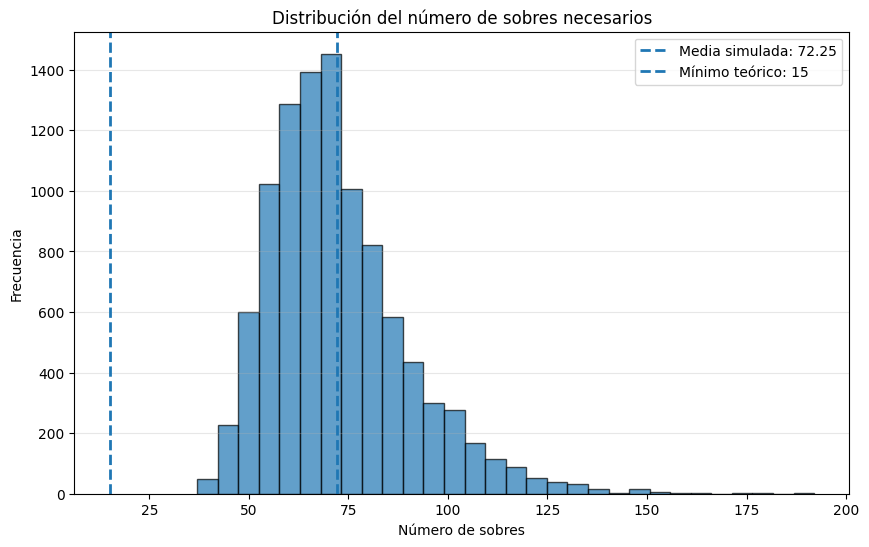

In [6]:
plt.figure(figsize=(10, 6))

plt.hist(sobres_necesarios, bins=30, edgecolor='black', alpha=0.7)

plt.axvline(media_sobres, linestyle='--', linewidth=2, label=f"Media simulada: {media_sobres:.2f}")
plt.axvline(minimo_teorico, linestyle='--', linewidth=2, label=f"Mínimo teórico: {minimo_teorico}")

plt.title("Distribución del número de sobres necesarios")
plt.xlabel("Número de sobres")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
precio_sobre = 9.50
precio_caja = 975.00
sobres_por_caja = 104

costo_esperado_sobres = media_sobres * precio_sobre

cajas_necesarias = np.ceil(sobres_necesarios / sobres_por_caja)
costo_promedio_cajas = np.mean(cajas_necesarias * precio_caja)

print(f"Costo esperado comprando sobres individuales: Q{costo_esperado_sobres:.2f}")
print(f"Costo promedio comprando cajas completas: Q{costo_promedio_cajas:.2f}")

## Preguntas de análisis

### 1. ¿Cuál es el número mínimo de sobres que se necesitarían si no hubiera estampas repetidas? ¿Se observa algún caso así en las simulaciones?

El número mínimo de sobres se obtiene dividiendo el total de estampas del álbum entre la cantidad de estampas que trae cada sobre:

\[
\frac{100}{7} \approx 14.2857
\]

Como no se pueden comprar fracciones de sobre, el mínimo teórico es:

\[
\lceil 100/7 \rceil = 15
\]

Esto significa que, en el mejor caso posible, se necesitarían al menos 15 sobres para completar el álbum reducido.

En las simulaciones no se observa este caso, ya que es extremadamente improbable que todos los sobres aporten únicamente estampas nuevas hasta completar la colección. En la práctica aparecen estampas repetidas, especialmente cuando ya se tiene una buena parte del álbum completado.

---

### 2. Calcular \(H_{100}\), obtener el valor teórico y comparar con la media de la simulación.

Para el álbum reducido se utiliza la teoría del coleccionista:

\[
E[T] \approx \frac{N}{S} H_N
\]

donde:

\[
N = 100
\]

\[
S = 7
\]

El número armónico es:

\[
H_{100} = \sum_{k=1}^{100} \frac{1}{k}
\]

También se puede aproximar como:

\[
H_{100} \approx \ln(100) + 0.5772
\]

Al sustituir en la fórmula:

\[
E[T] \approx \frac{100}{7}H_{100}
\]

Este valor representa el número esperado teórico de sobres necesarios para completar el álbum. Al compararlo con la media obtenida en la simulación, los valores deberían ser bastante cercanos, aunque no exactamente iguales, debido a la aleatoriedad propia del método Monte Carlo.

---

### 3. Calcular el valor esperado teórico del número de estampas repetidas y compararlo con la media de repetidas de la simulación.

El número de estampas repetidas puede estimarse a partir del total esperado de estampas compradas.

Si el número esperado de sobres es:

\[
E[T]
\]

entonces el número esperado de estampas compradas es:

\[
S \cdot E[T]
\]

Como el álbum tiene 100 estampas distintas, el valor esperado teórico de estampas repetidas es:

\[
E[\text{repetidas}] = S \cdot E[T] - N
\]

En este caso:

\[
E[\text{repetidas}] = 7 \cdot E[T] - 100
\]

Este resultado se compara con la media de estampas repetidas obtenida en la simulación. Si la simulación está bien implementada, ambos valores deberían ser similares.

---

### 4. ¿Cómo se interpreta la desviación estándar del número de sobres? ¿Es grande en relación con la media?

La desviación estándar indica qué tanto varía el número de sobres necesarios entre una simulación y otra.

En este problema, la desviación estándar suele ser considerable porque el proceso de completar un álbum tiene alta variabilidad. Al inicio, casi cada sobre aporta estampas nuevas, pero conforme el álbum se va llenando, cada vez es más difícil obtener las estampas faltantes.

Por eso, algunas simulaciones pueden completar el álbum con relativamente pocos sobres, mientras que otras pueden necesitar muchos más. Esto ocurre porque las últimas estampas faltantes pueden tardar bastante en aparecer.

En conclusión, el proceso de coleccionar estampas tiene una variabilidad alta, especialmente en la etapa final del álbum.